In [25]:
import numpy as np
import pandas as pd

In [26]:
messages = pd.read_csv('..//data/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

In [27]:
!pip install gensim

In [28]:
messages.isnull().sum()

label      0
message    0
dtype: int64

In [29]:
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
messages['label'] = messages['label'].map({'ham': 0, 'spam': 1})

In [31]:
messages.shape

(5572, 2)

In [32]:
messages['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

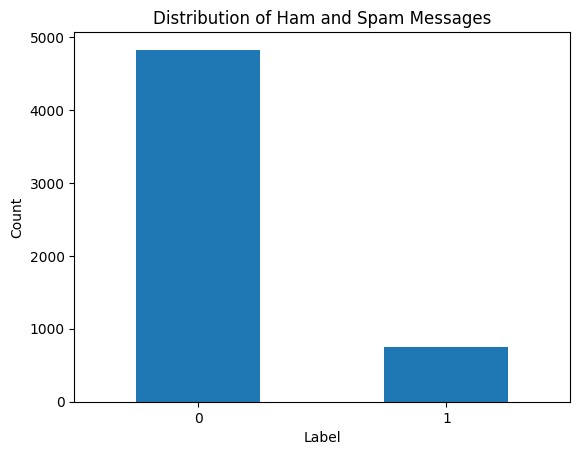

In [33]:
import matplotlib.pyplot as plt

messages['label'].value_counts().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Ham and Spam Messages')
plt.xticks(rotation=0)
plt.show()

In [34]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

In [35]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/apple/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/apple/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [36]:
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['message'][i])
    review = review.lower()
    review = review.split()
    
    review = [lemmatizer.lemmatize(word) for word in review]
    review = ' '.join(review)
    corpus.append(review)

In [37]:
corpus[:5]

['go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat',
 'ok lar joking wif u oni',
 'free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s',
 'u dun say so early hor u c already then say',
 'nah i don t think he go to usf he life around here though']

In [38]:
# [[i,j,k] for i,j,k in zip(list(map(len,corpus)),corpus, messages['message']) if i<1]


In [39]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [40]:
words=[]
for sent in corpus:
    sent_token=sent_tokenize(sent)
    for sent in sent_token:
        words.append(simple_preprocess(sent))

In [41]:
words

[['go',
  'until',
  'jurong',
  'point',
  'crazy',
  'available',
  'only',
  'in',
  'bugis',
  'great',
  'world',
  'la',
  'buffet',
  'cine',
  'there',
  'got',
  'amore',
  'wat'],
 ['ok', 'lar', 'joking', 'wif', 'oni'],
 ['free',
  'entry',
  'in',
  'wkly',
  'comp',
  'to',
  'win',
  'fa',
  'cup',
  'final',
  'tkts',
  'st',
  'may',
  'text',
  'fa',
  'to',
  'to',
  'receive',
  'entry',
  'question',
  'std',
  'txt',
  'rate',
  'apply',
  'over'],
 ['dun', 'say', 'so', 'early', 'hor', 'already', 'then', 'say'],
 ['nah',
  'don',
  'think',
  'he',
  'go',
  'to',
  'usf',
  'he',
  'life',
  'around',
  'here',
  'though'],
 ['freemsg',
  'hey',
  'there',
  'darling',
  'it',
  'been',
  'week',
  'now',
  'and',
  'no',
  'word',
  'back',
  'like',
  'some',
  'fun',
  'you',
  'up',
  'for',
  'it',
  'still',
  'tb',
  'ok',
  'xxx',
  'std',
  'chgs',
  'to',
  'send',
  'to',
  'rcv'],
 ['even',
  'my',
  'brother',
  'is',
  'not',
  'like',
  'to',
  'spea

In [42]:
from gensim.models import KeyedVectors
wv = KeyedVectors.load("..//word2vec.model")

In [43]:

import gensim
model=gensim.models.Word2Vec(words)


In [ ]:
def avg_word2vec(doc):
    
    vectors = [model.wv[word] for word in doc if word in model.wv.index_to_key]

    # if no valid words found
    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [45]:
from tqdm import tqdm

In [48]:
#apply for the entire sentences
import numpy as np
X=[]
for i in tqdm(range(len(words))):
    X.append(avg_word2vec(words[i]))

  0%|          | 0/5569 [00:00<?, ?it/s]

100%|██████████| 5569/5569 [00:00<00:00, 6923.77it/s]


In [ ]:
X=np.array(X)